In [49]:
import torch
import torch.nn as nn

x = torch.randn(3, 4)
target = torch.tensor([[1.0], [1.8], [2.7]])

model = nn.Linear(4, 1)
loss_fn = nn.MSELoss()

pred = model(x)
loss = loss_fn(pred, target)

print(f"pred: {pred}")
print(f"loss: {loss}")



pred: tensor([[-0.4697],
        [-0.1109],
        [-0.3962]], grad_fn=<AddmmBackward0>)
loss: 5.132585525512695


In [56]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(0)

# y = 2x + 1에 가까운 데이터
x = torch.linspace(-1, 1, 100).unsqueeze(1) # 차원 늘리기
# torch.Size([100]) -> torch.Size([100, 1])

y = 2 * x + 1 + 0.1 * torch.randn_like(x) # x와 같은 shape을 가지되, 각 원소를 정규분포 난수로 채운 텐서

base_model = nn.Linear(1, 1)
initial_state = {
    name: value.detach().clone()
    for name, value in base_model.state_dict().items()
}

def train_with_lr(lr, steps=50):
    model = nn.Linear(1, 1)
    model.load_state_dict(initial_state)

    loss_fn = nn.MSELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    losses = []
    for step in range(steps):
        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    return losses

loss_small = train_with_lr(lr=0.001)
loss_good = train_with_lr(lr=0.1)
loss_large = train_with_lr(lr=1.5)

print(f"small lr first/last: {loss_small[0]},{loss_small[-1]}")
print(f"good lr first/last: {loss_good[0]},{loss_good[-1]}")
print(f"large lr first/last: {loss_large[0]},{loss_large[-1]}")

small lr first/last: 2.6490726470947266,2.3744497299194336
good lr first/last: 2.6490726470947266,0.012222959659993649
large lr first/last: 2.6490726470947266,2.912103960059361e+29


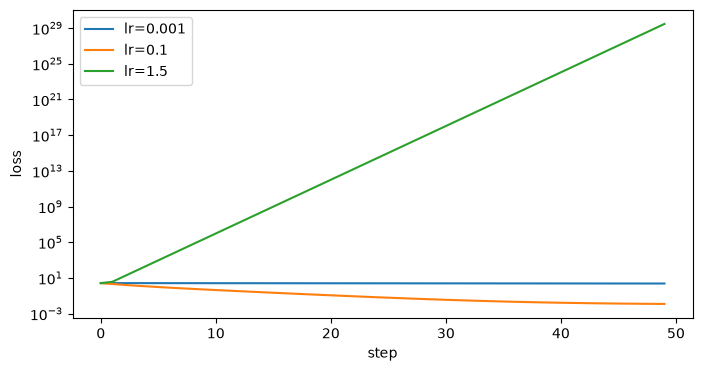

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_small, label="lr=0.001")
plt.plot(loss_good, label="lr=0.1")
plt.plot(loss_large, label="lr=1.5")
plt.xlabel("step")
plt.ylabel("loss")
plt.yscale("log")  # 작은 값과 폭증하는 값을 한 그래프에서 비교
plt.legend()
plt.show()

In [67]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

model_1 = nn.Linear(10, 2)
model_2 = nn.Linear(10, 2)
print(f"model_1:\n{tuple(model_1.parameters())}\n")
print(f"model_2:\n{tuple(model_2.parameters())}\n")


model_1.load_state_dict(model_2.state_dict())

optimizer_sgd = optim.SGD(model_1.parameters(), lr=0.01)
optimizer_adam = optim.Adam(model_2.parameters(), lr=0.001)

same_start = all(
    torch.equal(p_sgd, p_adam)
    for p_sgd, p_adam in zip(model_1.parameters(), model_2.parameters())
)
assert same_start

print("same initial parameters:", same_start)
print("SGD updates model_sgd :", optimizer_sgd)
print("Adam updates model_adam:", optimizer_adam)

model_1:
(Parameter containing:
tensor([[ 0.2418,  0.2625, -0.0741,  0.2905, -0.0693,  0.0638, -0.1540,  0.1857,
          0.2788, -0.2320],
        [ 0.2749,  0.0592,  0.2336,  0.0428,  0.1525, -0.0446,  0.2438,  0.0467,
         -0.1476,  0.0806]], requires_grad=True), Parameter containing:
tensor([-0.1457, -0.0371], requires_grad=True))

model_2:
(Parameter containing:
tensor([[-0.1284,  0.2098, -0.2496, -0.1458, -0.0893, -0.1901,  0.0298, -0.3123,
          0.2856, -0.2686],
        [ 0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,  0.0346, -0.0997,
          0.0850, -0.0858]], requires_grad=True), Parameter containing:
tensor([0.1331, 0.2823], requires_grad=True))

same initial parameters: True
SGD updates model_sgd : SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
Adam updates model_adam: Adam (
Parameter Group 0
    amsgrad: False
 